# ЧЕКПОИНТ 3

In [3]:
import random
import numpy as np
import pandas as pd
import os
import warnings

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression

from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)


seed_everything()

## Целевая переменная


**В качестве целевой переменно выбираем лог-доходность:**
- не зависит от масштаба цены
- делает ряд почти стационарным, колеблется вокруг нуля
- хорошо подходит для ML, прогнозы на несколько шагов вперед
- аддитивна во времени (можно складывать доходности разных моделей и рассчитывать портфели и волатильность)
- возможны отрицательные значения
- позволяет перейти к прогнозируемой цене
- можно применить SARIMA модель

## Метрики

**Выбираем метрики для оценки качества**

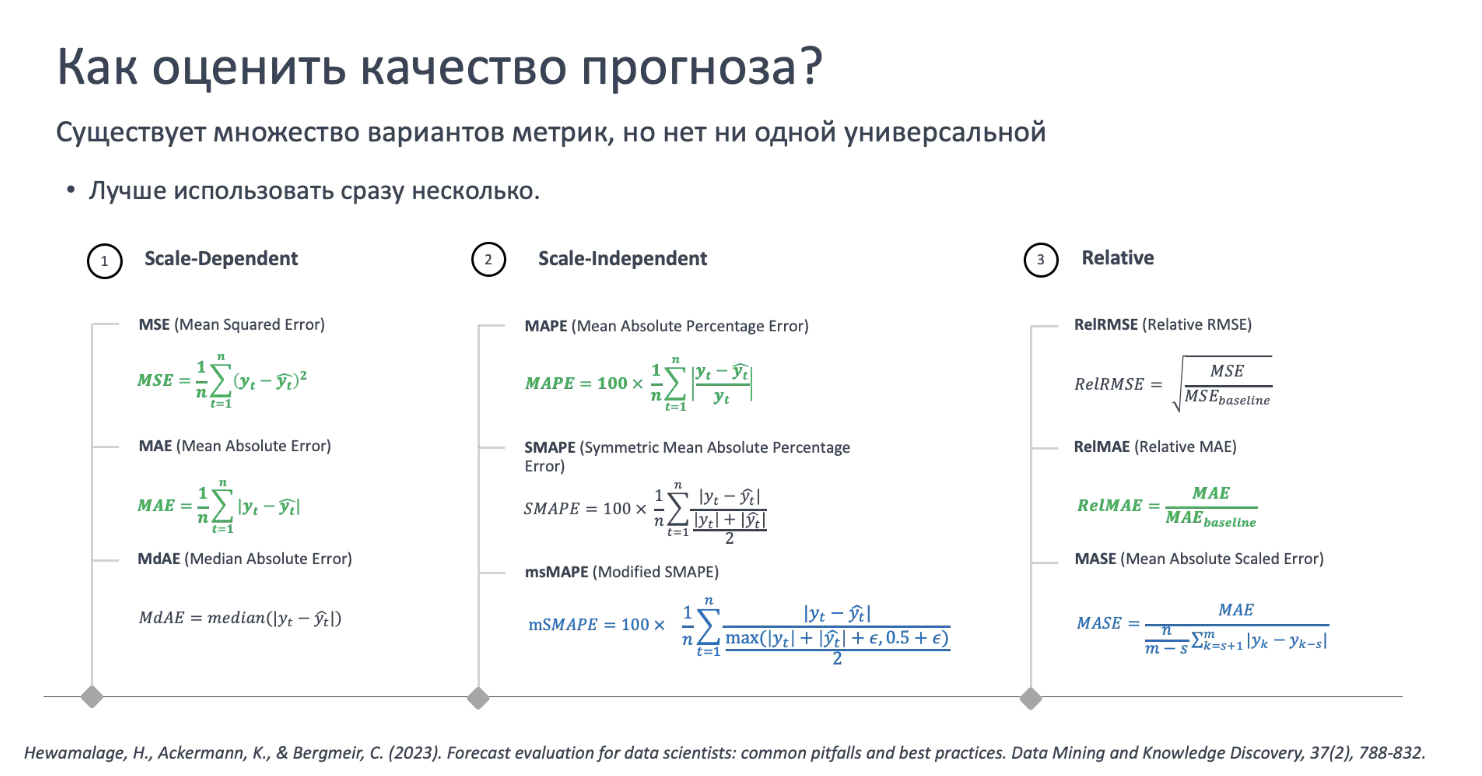

**Надо учесть, что мы прогнозируем лог-доходность:**
- лог-доходности маленькие
- масштаб одинаковый для всех активов
- возможны отрицательные значения
- вариации MAPE не применимы

**Выбираем RMSE как основную метрику:**
- не зависит от масштаба цены (у нас много рядов)

**В качестве дополнительной метрики будем использовать MASE (Mean Absolute Scaled Error):**
- сравнивает модель с наивной (работает ли она вообще лучше)
- не зависит от масштаба
- подходит для данных, где есть отрицательные значения

In [273]:
def rmse(y_predict, y_test):
    return np.sqrt(np.mean((y_test - y_predict) ** 2))


def mase(y_predict, y_train, y_test):
    # MAE наивного прогноза (y_t - y_{t-1}) на train
    train_values = y_train.values
    naive_errors = np.abs(train_values[1:] - train_values[:-1])
    mae_naive = naive_errors.mean()

    mae_model = np.abs(y_test.values - y_predict).mean()

    return mae_model / mae_naive

## Подготовка данных

**Рассмотрим Top10** акций

In [274]:
# Тикеты
SECIDS = ['GAZP', 'GMKN', 'LKOH', 'NVTK', 'PIKK', 'ROSN', 'SBER', 'T', 'VTBR', 'YDEX']


def merge_csv_files(output_file="data/moex/moex_top10_liquid.csv") -> pd.DataFrame:
    """
    Объединяет CSV файлы для заданных тикеров в один DataFrame
    """
    dfs = []
    missing_files = []

    for secid in SECIDS:
        filename = f"data/moex/moex_{secid}.csv"
        if os.path.exists(filename):
            try:
                print(f"Читаю файл: {filename}")
                df = pd.read_csv(filename)
                #dfs.append(df)
                dfs.append(fill_missing_dates(df))
            except Exception as e:
                print(f"Ошибка при чтении файла {filename}: {e}")
        else:
            print(f"Файл не найден: {filename}")
            missing_files.append(filename)

    if len(dfs) == 0:
        raise ValueError("❗️Ничего не удалось прочитать!")

    result_df = pd.concat(dfs, ignore_index=True)

    # Выводим статистику
    print(f"\n{'='*50}")
    print(f"Обработка завершена:")
    print(f"- Успешно прочитано: {len(dfs)} файлов")

    if missing_files:
        print(f"- Не найдено файлов: {len(missing_files)}")
        print(f"- Отсутствующие файлы: {', '.join(missing_files)}")
    else:
        print(f"- Размер DataFrame: {result_df.shape}")
        result_df.to_csv(output_file, index=False)
        print(f"Результат сохранен в {output_file}")

    print(f"{'='*50}")

    return result_df


def fill_missing_dates(df, column="TRADEDATE") -> pd.DataFrame:
    """
    Заполняет пропуски и добавляет флаг выходного дня.
    Forward fill (заполнение последним значением)
    """
    # Преобразуем колонку с датами в datetime
    df = df.copy()
    df[column] = pd.to_datetime(df[column])

    # Сортируем по дате
    df = df.sort_values(by=column).reset_index(drop=True)

    # Создаем полный диапазон дат от минимальной до максимальной
    min_date = df[column].min()
    max_date = df[column].max()
    full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

    # Создаем DataFrame с полным диапазоном дат
    full_df = pd.DataFrame({column: full_date_range})

    # Объединяем с исходными данными
    df_filled = full_df.merge(df, on=column, how='left')

    # Добавляем признак IS_WORK_DAY (1 для существующих строк, 0 для вставленных) и проверяем, есть ли хотя бы одна непустая колонка кроме даты
    other_columns = [col for col in df.columns if col != column]
    df_filled['IS_WORK_DAY'] = df_filled[other_columns].notna().any(axis=1).astype(int)

    # Заполняем пропуски forward fill для всех колонок кроме даты
    df_filled[other_columns] = df_filled[other_columns].ffill()

    # Сортируем по дате
    df_filled = df_filled.sort_values(by=column).reset_index(drop=True)

    return df_filled


df_merged = merge_csv_files()
df_merged


Читаю файл: data/moex/moex_GAZP.csv
Читаю файл: data/moex/moex_GMKN.csv
Читаю файл: data/moex/moex_LKOH.csv
Читаю файл: data/moex/moex_NVTK.csv
Читаю файл: data/moex/moex_PIKK.csv
Читаю файл: data/moex/moex_ROSN.csv
Читаю файл: data/moex/moex_SBER.csv
Читаю файл: data/moex/moex_T.csv
Читаю файл: data/moex/moex_VTBR.csv
Читаю файл: data/moex/moex_YDEX.csv

Обработка завершена:
- Успешно прочитано: 10 файлов
- Размер DataFrame: (32684, 25)
Результат сохранен в data/moex/moex_top10_liquid.csv


,TRADEDATE,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,...,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE,IS_WORK_DAY
0,2014-06-09,TQBR,ГАЗПРОМ ао,GAZP,32981.0,5.851239e+09,144.00,143.03,146.20,144.40,...,145.02,5.850366e+09,5.850366e+09,5.850366e+09,NaN,3.0,SUR,0.30,NaN,1
1,2014-06-10,TQBR,ГАЗПРОМ ао,GAZP,34667.0,5.956067e+09,144.31,142.67,144.76,144.75,...,143.65,5.954475e+09,5.954475e+09,5.954475e+09,NaN,3.0,SUR,0.24,NaN,1
2,2014-06-11,TQBR,ГАЗПРОМ ао,GAZP,35615.0,5.725373e+09,145.20,143.90,146.40,146.40,...,145.25,5.722179e+09,5.722179e+09,5.722179e+09,NaN,3.0,SUR,1.14,NaN,1
3,2014-06-12,TQBR,ГАЗПРОМ ао,GAZP,35615.0,5.725373e+09,145.20,143.90,146.40,146.40,...,145.25,5.722179e+09,5.722179e+09,5.722179e+09,NaN,3.0,SUR,1.14,NaN,0
4,2014-06-13,TQBR,ГАЗПРОМ ао,GAZP,35615.0,5.725373e+09,145.20,143.90,146.40,146.40,...,145.25,5.722179e+09,5.722179e+09,5.722179e+09,NaN,3.0,SUR,1.14,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32679,2025-12-01,TQBR,ЯНДЕКС,YDEX,28505.0,1.772269e+09,4193.00,4166.00,4220.00,4204.00,...,NaN,1.245876e+09,1.245876e+09,NaN,0.0,3.0,SUR,0.17,2025-12-01,1
32680,2025-12-02,TQBR,ЯНДЕКС,YDEX,34881.0,3.186514e+09,4190.00,4182.00,4239.50,4226.50,...,NaN,2.772989e+09,2.772989e+09,NaN,0.0,3.0,SUR,0.67,2025-12-02,1
32681,2025-12-03,TQBR,ЯНДЕКС,YDEX,27430.0,1.863971e+09,4192.00,4120.00,4220.00,4169.00,...,NaN,1.182937e+09,1.182937e+09,NaN,0.0,3.0,SUR,-1.18,2025-12-03,1
32682,2025-12-04,TQBR,ЯНДЕКС,YDEX,21244.0,1.492581e+09,4177.00,4166.50,4233.50,4209.00,...,NaN,1.235175e+09,1.235175e+09,NaN,0.0,3.0,SUR,0.76,2025-12-04,1


**Для рисования графиков будем использовать Plotly.**

Несколько полезных ссылок:
- Вводная статья про Plotly (на русском): https://habr.com/ru/articles/502958/.

- Галерея графиков с примерами кода: https://plotly.com/python/.

- Time Series and Date Axes in Python: https://plotly.com/python/time-series/.

In [275]:
fig = go.Figure()

for secid in SECIDS:
    fig.add_trace(
        go.Scatter(x=df_merged[df_merged["SECID"] == secid]["TRADEDATE"], y=df_merged[df_merged["SECID"] == secid]["LEGALCLOSEPRICE"], name=secid)
    )

fig.update_layout(
    title="TOP 10 MOEX",
    xaxis_title="Дата",
    yaxis_title="Цена",
)

fig.show()

__Вывод:__
- Масштаб цен сильно отличается
- Ряды начинаются с разного времени

**Количество пропусков по столбцам**

In [276]:
df_merged.isnull().sum()

TRADEDATE                      0
BOARDID                        0
SHORTNAME                      0
SECID                          0
NUMTRADES                      0
VALUE                          0
OPEN                          88
LOW                           88
HIGH                          88
LEGALCLOSEPRICE               16
WAPRICE                       88
CLOSE                         88
VOLUME                         0
MARKETPRICE2                  16
MARKETPRICE3                  16
ADMITTEDQUOTE               1496
MP2VALTRD                      0
MARKETPRICE3TRADESVALUE        0
ADMITTEDVALUE               1496
WAVAL                      17535
TRADINGSESSION                 0
CURRENCYID                     0
TRENDCLSPR                    99
TRADE_SESSION_DATE         30182
IS_WORK_DAY                    0
dtype: int64

**Количество нулей по столбцам**


In [277]:
(df_merged == 0).sum()

TRADEDATE                      0
BOARDID                        0
SHORTNAME                      0
SECID                          0
NUMTRADES                    405
VALUE                        405
OPEN                           0
LOW                            0
HIGH                           0
LEGALCLOSEPRICE                0
WAPRICE                        0
CLOSE                          0
VOLUME                       405
MARKETPRICE2                   0
MARKETPRICE3                   0
ADMITTEDQUOTE                  0
MP2VALTRD                    101
MARKETPRICE3TRADESVALUE       16
ADMITTEDVALUE                 85
WAVAL                      15149
TRADINGSESSION                 0
CURRENCYID                     0
TRENDCLSPR                   666
TRADE_SESSION_DATE             0
IS_WORK_DAY                10044
dtype: int64

__Вывод:__
- На данном этапе нас интересует TRADEDATE и LEGALCLOSEPRICE - всё хорошо по ним.

### Для анализа возьмем один ряд - SBER

In [278]:
# SBER
series_name = "SBER"
df_series = df_merged[df_merged["SECID"] == series_name].copy()

# Добавляем целевую переменную
df_series["LOG_RETURN"] = np.log(df_merged["LEGALCLOSEPRICE"] / df_merged["LEGALCLOSEPRICE"].shift(1))

# Итоговый ряд
df_series = df_series[["TRADEDATE", "LEGALCLOSEPRICE", "LOG_RETURN", "IS_WORK_DAY"]]
df_series

,TRADEDATE,LEGALCLOSEPRICE,LOG_RETURN,IS_WORK_DAY
22815,2013-03-25,98.66,-1.424112,1
22816,2013-03-26,97.13,-0.015629,1
22817,2013-03-27,96.73,-0.004127,1
22818,2013-03-28,98.64,0.019553,1
22819,2013-03-29,98.83,0.001924,1
...,...,...,...,...
27449,2025-12-01,305.70,0.003211,1
27450,2025-12-02,303.30,-0.007882,1
27451,2025-12-03,303.36,0.000198,1
27452,2025-12-04,301.95,-0.004659,1


In [279]:
HORIZON = 30


# Разделим данные на обучающую и тестовую выборки
train_size = len(df_series) - HORIZON
train_split_date = np.sort(df_series["TRADEDATE"])[train_size]

df_train = df_series[df_series["TRADEDATE"] < train_split_date]
df_test = df_series[df_series["TRADEDATE"] >= train_split_date]


# Отобразим
fig = go.Figure()
df_fig = df_train[df_train["TRADEDATE"] >= "2025-01-01"]
fig.add_trace(
    go.Scatter(x=df_fig["TRADEDATE"], y=df_fig["LOG_RETURN"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=df_test["TRADEDATE"], y=df_test["LOG_RETURN"], name="Test", line=dict(color="red"))
)
fig.update_layout(
    title="Train/Test", xaxis_title="TRADEDATE", yaxis_title="LOG_RETURN"
)
fig.show()

## Тесты на стационарность

**Рассмотрим два наиболее популярных теста на стационарность:**
- Тест Дики-Фуллера (Augmented Dickey-Fuller test) — https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html
- KPSS-тест (Kwiatkowski-Phillips-Schmidt-Shin test) — https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.kpss.html

In [280]:
warnings.filterwarnings("ignore", category=InterpolationWarning)

# KPSS тест
statistic, p_value, lags, critical_values = kpss(df_train["LOG_RETURN"])
print(f"KPSS p-value: {p_value}")

# ADF тест
statistic, p_value, usedlag, _, critical_values, icbest = adfuller(df_train["LOG_RETURN"])
print(f"ADF p-value: {p_value}")

KPSS p-value: 0.1
ADF p-value: 0.0


__Вывод:__
- KPSS p-value = 0.1 - ряд стационарный (не отвергаем гипотезу H₀ о стационарности)
- ADF p-value = 0.0 - ряд стационарный (отвергаем гипотезу о единичном корне)



## Выбор модели

### Линейная регрессия (по лагам)

In [281]:
def make_lags(series, lags) -> pd.DataFrame:
    return pd.concat({f"lag_{i}": series.shift(i) for i in range(1, lags + 1)}, axis=1)


results = {"RMSE": {}, "MASE": {}}
predicts = {}

# Перебор для разных лагов
for LAGS in [1, 5, 7]:
    # Train
    lags_train = make_lags(df_train["LOG_RETURN"], LAGS)
    data_train = pd.concat([df_series[["TRADEDATE"]], df_train["LOG_RETURN"], lags_train], axis=1).dropna()
    X_train = data_train[lags_train.columns]
    y_train_lr = data_train["LOG_RETURN"]

    # Test
    lags_test = make_lags(df_test["LOG_RETURN"], LAGS)
    data_test = pd.concat([df_series[["TRADEDATE"]], df_test["LOG_RETURN"], lags_test], axis=1).dropna()
    X_test = data_test[lags_test.columns]
    y_test_lr = data_test["LOG_RETURN"]

    # Обучение
    lr = LinearRegression()
    lr.fit(X_train, y_train_lr)

    # Прогноз
    y_lr_pred = lr.predict(X_test)
    predicts[LAGS] = y_lr_pred

    # Метрики
    rmse_value = rmse(y_lr_pred, y_test_lr)
    mase_value = mase(y_lr_pred, y_train_lr, y_test_lr)
    results["RMSE"][LAGS] = rmse_value
    results["MASE"][LAGS] = mase_value


In [282]:
# Значения полученных метрик
df = pd.DataFrame(results)
df.index.name = "LAGS"
df

,RMSE,MASE
LAGS,,
1,0.008939,0.434601
5,0.009038,0.453183
7,0.009252,0.467403


### SARIMA


Правила построения SARIMA модели хорошо описаны в этой статье: https://people.duke.edu/~rnau/arimrule.htm

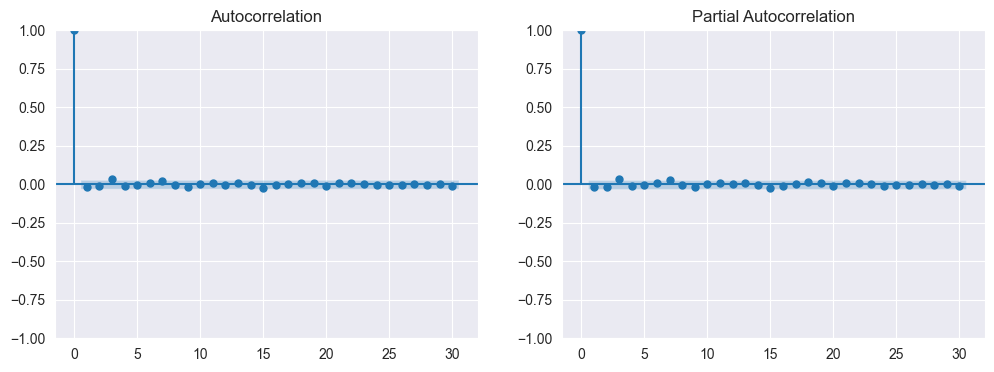

In [283]:
# ACF и PACF
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_pacf(df_train["LOG_RETURN"], lags=30, ax=ax[1])
plot_acf(df_train["LOG_RETURN"], lags=30, ax=ax[0])
plt.show()

__Вывод__:
- p = 0 — PACF показывает отсутствие значимых автокорреляций (нет AR-компоненты)
- q = 0 — ACF тоже пустой (нет MA-компоненты)
- d = 0 — т.к. лог-доходность стационарна

D:\YandexDisk\idenisger\Edu\StocksForecast\ai_portfolio\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

D:\YandexDisk\idenisger\Edu\StocksForecast\ai_portfolio\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.



                               SARIMAX Results                                
Dep. Variable:             LOG_RETURN   No. Observations:                 4609
Model:               SARIMAX(1, 0, 1)   Log Likelihood                9881.328
Date:                Wed, 14 Jan 2026   AIC                         -19756.656
Time:                        18:21:51   BIC                         -19737.349
Sample:                             0   HQIC                        -19749.861
                               - 4609                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2114      0.254      0.831      0.406      -0.287       0.710
ma.L1         -0.2577      0.253     -1.018      0.309      -0.754       0.238
sigma2         0.0008   7.49e-07   1072.934      0.0

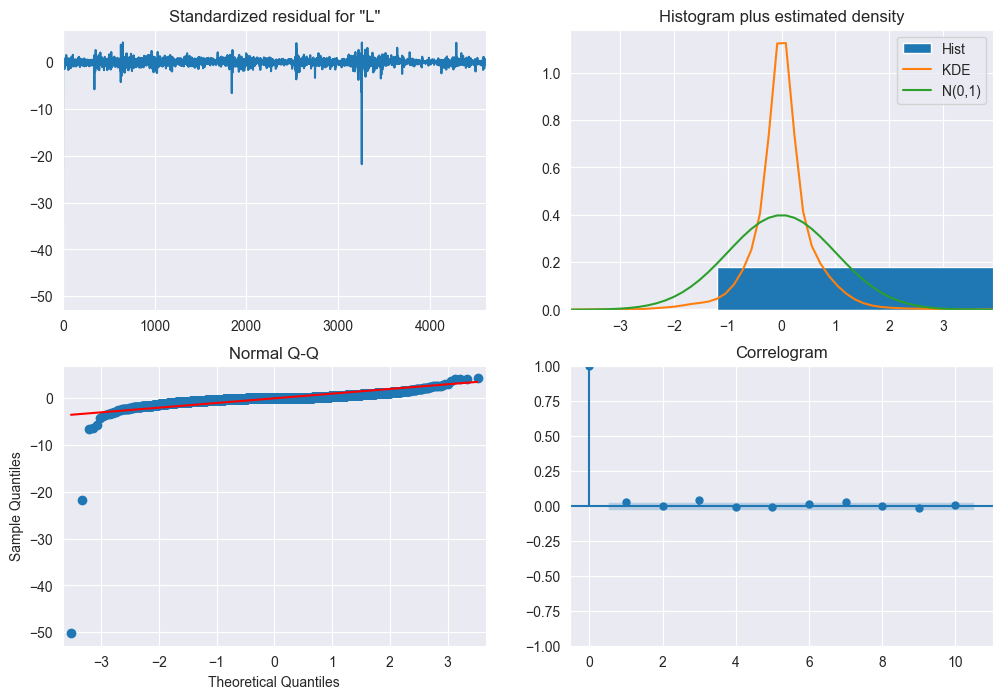

In [284]:
model = SARIMAX(
    df_train["LOG_RETURN"],
    order=(1, 0, 1), # берем небольшие значения ARIMA(p,d,q)
    seasonal_order=(0, 0, 0, 0), # без сезонности
    enforce_stationarity=True,
    enforce_invertibility=True
)

model_fit = model.fit(disp=False)
print(model_fit.summary())

model_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

In [285]:
predict = model_fit.get_forecast(steps=HORIZON)
y_pred_auto = predict.predicted_mean.reset_index(drop=True)

df_predict = pd.DataFrame({"TRADEDATE": df_test["TRADEDATE"], "LOG_RETURN": y_pred_auto.values})
df_predict

D:\YandexDisk\idenisger\Edu\StocksForecast\ai_portfolio\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

D:\YandexDisk\idenisger\Edu\StocksForecast\ai_portfolio\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



,TRADEDATE,LOG_RETURN
27424,2025-11-06,3.775220e-04
27425,2025-11-07,7.979876e-05
27426,2025-11-08,1.686748e-05
27427,2025-11-09,3.565365e-06
27428,2025-11-10,7.536297e-07
27429,2025-11-11,1.592986e-07
27430,2025-11-12,3.367176e-08
27431,2025-11-13,7.117374e-09
27432,2025-11-14,1.504436e-09
27433,2025-11-15,3.180004e-10


In [286]:
rmse_value = rmse(df_predict["LOG_RETURN"], df_test["LOG_RETURN"])
print("RMSE:", rmse_value)

mase_value = mase(df_predict["LOG_RETURN"], df_train["LOG_RETURN"], df_test["LOG_RETURN"])
print("MASE:", mase_value)


RMSE: 0.008872418574827115
MASE: 0.4163219980057422


### Вывод:
- Модель SARIMA показала лучший результат по сравнению с линейной регрессией.
- Модель в среднем ошибается в 2.4 раза меньше, чем наивная модель.
- Прогноз лог-доходности ошибается примерно на 0.9% изменения цены.

### Графическое отображение


In [287]:
fig = go.Figure()
df_fig = df_train[df_train["TRADEDATE"] >= "2025-01-01"]
fig.add_trace(
    go.Scatter(x=df_fig["TRADEDATE"], y=df_fig["LOG_RETURN"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=df_test["TRADEDATE"], y=df_test["LOG_RETURN"], name="Test", line=dict(color="red"))
)
fig.add_trace(
    go.Scatter(
        x=df_predict["TRADEDATE"], y=df_predict["LOG_RETURN"], name="Predictions", line=dict(color="green")
    )
)
fig.update_layout(
    title="Train/Test/Predict", xaxis_title="TRADEDATE", yaxis_title="LOG_RETURN"
)
fig.show()

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df_predict["TRADEDATE"], y=df_predict["LOG_RETURN"], name="Predictions", line=dict(color="green")
    )
)
fig.update_layout(
    title="Predict", xaxis_title="TRADEDATE", yaxis_title="LOG_RETURN"
)
fig.show()


### Пробуем улучшить. AutoARIMA


In [288]:
# AutoARIMA через менеджер StatsForecast
stats_models = [AutoARIMA(seasonal=False)]
stats_auto = StatsForecast(models=stats_models, freq='D')

# Подготовка данных для StatsForecast: нужен формат  | unique_id | ds | y |
df_train_sf = df_train.copy()
df_train_sf.drop(columns=["IS_WORK_DAY", "LEGALCLOSEPRICE"], inplace=True)
df_train_sf["unique_id"] = "1"
df_train_sf.rename(columns={"TRADEDATE": "ds", "LOG_RETURN": "y"}, inplace=True)

# Обучение
stats_auto.fit(df_train_sf)

# Предсказание
y_pred_auto = stats_auto.predict(h=len(df_test))
predictions = pd.DataFrame({"date": y_pred_auto["ds"], "y": y_pred_auto["AutoARIMA"]})
predictions


,date,y
0,2025-11-06,0.002921
1,2025-11-07,0.001292
2,2025-11-08,-0.001671
3,2025-11-09,-0.001320
4,2025-11-10,0.000282
5,2025-11-11,0.001422
6,2025-11-12,0.000535
7,2025-11-13,-0.001026
8,2025-11-14,-0.001076
9,2025-11-15,0.000352


In [289]:
rmse_value = rmse(y_pred_auto["AutoARIMA"].values, df_test["LOG_RETURN"])
print("RMSE:", rmse_value)

mase_value = mase(y_pred_auto["AutoARIMA"], df_train["LOG_RETURN"], df_test["LOG_RETURN"])
print("MASE:", mase_value)

RMSE: 0.008994986643691711
MASE: 0.4380515917378572


__Вывод:__
- Не удалось улучшить качество с помощью AutoARIMA

## Применяем модель для топ акций

In [294]:
SECIDS = ['GAZP', 'GMKN', 'LKOH', 'NVTK', 'PIKK', 'ROSN', 'SBER', 'T', 'YDEX'] #VTBR

HORIZON = 30


for series_name in SECIDS:
    df_series = df_merged[df_merged["SECID"] == series_name].copy()

    # Добавляем целевую переменную
    df_series["LOG_RETURN"] = np.log(df_merged["LEGALCLOSEPRICE"] / df_merged["LEGALCLOSEPRICE"].shift(1))

    # Итоговый ряд
    df_series = df_series[["TRADEDATE", "LEGALCLOSEPRICE", "LOG_RETURN", "IS_WORK_DAY"]]

    # Разделим данные на обучающую и тестовую выборки
    train_size = len(df_series) - HORIZON
    train_split_date = np.sort(df_series["TRADEDATE"])[train_size]

    df_train = df_series[df_series["TRADEDATE"] < train_split_date]
    df_test = df_series[df_series["TRADEDATE"] >= train_split_date]

    # Отобразим
    fig = go.Figure()
    df_fig = df_train[df_train["TRADEDATE"] >= "2025-01-01"]
    fig.add_trace(
        go.Scatter(x=df_fig["TRADEDATE"], y=df_fig["LOG_RETURN"], name="Train", line=dict(color="blue"))
    )
    fig.add_trace(
        go.Scatter(x=df_test["TRADEDATE"], y=df_test["LOG_RETURN"], name="Test", line=dict(color="red"))
    )
    fig.add_trace(
        go.Scatter(
            x=df_predict["TRADEDATE"], y=df_predict["LOG_RETURN"], name="Predictions", line=dict(color="green")
        )
    )
    fig.update_layout(
        title=series_name, xaxis_title="TRADEDATE", yaxis_title="LOG_RETURN"
    )
    fig.show()

